In [1]:
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

DB_PATH = Path("../data/raw/ventas.db")
conn = sqlite3.connect(DB_PATH)

def sql(query, params=None):
    return pd.read_sql_query(query, conn, params=params)

# Auditoria de calidad con SQL

## Cuántas ventas tienen cantidad negativa o cero.

In [2]:
# Prueba
# Tablas: clientes, productos, ventas
sql("SELECT COUNT(*) AS ventas_invalidas FROM ventas WHERE cantidad <= 0")

,ventas_invalidas
0,0


## Huérfanos de integridad referencial

In [3]:
sql("SELECT * FROM ventas WHERE cliente_id NOT IN (SELECT cliente_id FROM clientes)")

,venta_id,cliente_id,producto_id,cantidad,fecha_venta,descuento_pct


## Cantidad de descuentos nulos

In [4]:
sql("select * from ventas where descuento_pct is null")

,venta_id,cliente_id,producto_id,cantidad,fecha_venta,descuento_pct


## Cantidad de descuentos iguales a 0

In [5]:
sql("select count(*) from ventas where descuento_pct = 0")

,count(*)
0,192


## Correcion de valores Nulos en descuento_pct

In [6]:
df_ventas = sql("select * from ventas")
df_ventas = df_ventas.dropna(subset=["descuento_pct"])
df_ventas.to_sql("ventas", conn, index=False, if_exists="replace")

379

## Duplicados en tabla Ventas

In [7]:
df_ventas[df_ventas.duplicated()]

,venta_id,cliente_id,producto_id,cantidad,fecha_venta,descuento_pct


# Limpieza de Datos

In [8]:
# Limpieza de datos - Cantidad
sql("select count(*) from ventas where cantidad <= 0")

,count(*)
0,0


In [9]:
print("Antes:", len(df_ventas))

df_ventas = df_ventas[df_ventas["cantidad"] > 0]

print("Después:", len(df_ventas))

df_ventas.to_sql("ventas", conn, index=False, if_exists="replace")

Antes: 379
Después: 379


379

In [10]:
sql("select * from ventas where cliente_id not in (select cliente_id from clientes)")

,venta_id,cliente_id,producto_id,cantidad,fecha_venta,descuento_pct


In [11]:
# Limpieza de datos - Huerfanos
df_ventas = df_ventas[df_ventas["cliente_id"] != 999]
df_ventas.to_sql("ventas", conn, index=False, if_exists="replace")

379

In [12]:
# Limpieza de datos - 
print(f"Antes:  {len(df_ventas)}")
df_ventas.drop_duplicates(inplace=True)
print(f"Despues:  {len(df_ventas)}")
df_ventas.to_sql("ventas", conn, index=False, if_exists="replace")

Antes:  379
Despues:  379


379

In [13]:
# Limpieza de datos - Normalizacion de Segmentos en la tabla clientes
sql("select distinct segmento from clientes")

,segmento
0,estandar
1,basico
2,premium


In [14]:
df_clientes = sql("select * from clientes")
df_clientes.tail()

,cliente_id,nombre_cliente,ciudad,segmento,fecha_registro
55,56,Cliente_56,Medellín,premium,2024-04-05
56,57,Cliente_57,Barranquilla,estandar,2024-04-20
57,58,Cliente_58,Barranquilla,premium,2024-05-05
58,59,Cliente_59,Barranquilla,estandar,2024-05-20
59,60,Cliente_60,Medellín,basico,2024-06-04


In [15]:
df_clientes["segmento"].unique()

<StringArray>
['estandar', 'basico', 'premium']
Length: 3, dtype: str

In [16]:
# Normalizar textos de la columna segmento
df_clientes["segmento"] = df_clientes["segmento"].str.lower().str.strip()

In [17]:
df_clientes["segmento"].unique()

<StringArray>
['estandar', 'basico', 'premium']
Length: 3, dtype: str

In [18]:
# Mapeo para estandarizar los valores dentro de la columna segmento
map_segmento = {
    "estándar": "estandar",
    "básico": "basico"
}

df_clientes["segmento"] = df_clientes["segmento"].replace(map_segmento)
df_clientes["segmento"].unique()

<StringArray>
['estandar', 'basico', 'premium']
Length: 3, dtype: str

In [19]:
df_clientes.to_sql("clientes", conn, index=False, if_exists="replace")

60

# Analisis con JOINS SQL

In [20]:
sql("select * from productos limit 1")

,producto_id,nombre_producto,categoria,precio_unitario,costo_unitario
0,1,Producto_1,Belleza,437600.0,73600.0


In [21]:
sql("select * from ventas limit 1")

,venta_id,cliente_id,producto_id,cantidad,fecha_venta,descuento_pct
0,1,23,3,6,2024-09-21,0.0


In [22]:
sql("select * from clientes limit 1")

,cliente_id,nombre_cliente,ciudad,segmento,fecha_registro
0,1,Cliente_1,Cartagena,estandar,2022-01-01


In [23]:
sql("""
SELECT
    p.categoria,
    SUM(cantidad * precio_unitario * (1 - descuento_pct / 100.0)) AS ingreso_total
FROM ventas v
JOIN productos p
    ON v.producto_id = p.producto_id
GROUP BY p.categoria
ORDER BY ingreso_total DESC;
""")

,categoria,ingreso_total
0,Electrónica,128378110.0
1,Belleza,111751495.0
2,Ropa,39616945.0
3,Hogar,25918470.0
4,Deportes,13553645.0


In [24]:
sql("""
SELECT
    c.ciudad,
    SUM(cantidad * precio_unitario * (1 - descuento_pct / 100.0)) AS ingreso_total
FROM clientes c
JOIN ventas v
    ON c.cliente_id = v.cliente_id
JOIN productos p
    ON v.producto_id = p.producto_id
GROUP BY c.ciudad
ORDER BY ingreso_total DESC;
""")

,ciudad,ingreso_total
0,Barranquilla,73263795.0
1,Bogotá,68367855.0
2,Cartagena,63803450.0
3,Medellín,55615430.0
4,Bucaramanga,36450380.0
5,Cali,21717755.0


In [25]:
sql("""
SELECT
    c.segmento,
    AVG(
        v.cantidad * p.precio_unitario * (1 - v.descuento_pct / 100.0)
    ) AS ticket_promedio
FROM ventas v
JOIN clientes c
    ON v.cliente_id = c.cliente_id
JOIN productos p
    ON v.producto_id = p.producto_id
GROUP BY c.segmento
ORDER BY ticket_promedio DESC;
""")

,segmento,ticket_promedio
0,estandar,901342.645631
1,premium,781360.126582
2,basico,763985.425532


In [26]:
sql("""
SELECT
    p.nombre_producto,
    SUM(v.cantidad * p.precio_unitario * (1 - v.descuento_pct / 100.0)) AS total_ingresos
FROM productos p
JOIN ventas v
    ON p.producto_id = v.producto_id
GROUP BY p.producto_id, p.nombre_producto
HAVING SUM(v.cantidad * p.precio_unitario * (1 - v.descuento_pct / 100.0)) > (
    SELECT AVG(ingreso_total)
    FROM (
        SELECT
            SUM(v.cantidad * p.precio_unitario * (1 - v.descuento_pct / 100.0)) AS ingreso_total
        FROM productos p
        JOIN ventas v
            ON p.producto_id = v.producto_id
        GROUP BY p.producto_id
    ) t
)
ORDER BY total_ingresos DESC
""")

,nombre_producto,total_ingresos
0,Producto_1,37305400.0
1,Producto_23,35509320.0
2,Producto_8,28458480.0
3,Producto_22,27312870.0
4,Producto_14,21822420.0
5,Producto_6,19776270.0
6,Producto_16,19246720.0
7,Producto_13,13769070.0
8,Producto_11,13452740.0
9,Producto_25,12806550.0


# Graficos de Barras

In [27]:
df_clientes = sql("select * from clientes")
df_ventas = sql("select * from ventas")
df_productos = sql("select * from productos")

In [28]:
df_productos.head(1)

,producto_id,nombre_producto,categoria,precio_unitario,costo_unitario
0,1,Producto_1,Belleza,437600.0,73600.0


In [29]:
df_clientes.head(1)

,cliente_id,nombre_cliente,ciudad,segmento,fecha_registro
0,1,Cliente_1,Cartagena,estandar,2022-01-01


In [30]:
df_ventas.head(1)

,venta_id,cliente_id,producto_id,cantidad,fecha_venta,descuento_pct
0,1,23,3,6,2024-09-21,0.0


In [31]:
df_IngresoTotalCategoria = sql("""
SELECT
    p.categoria,
    SUM(cantidad * precio_unitario * (1 - descuento_pct / 100.0)) AS ingreso_total
FROM ventas v
JOIN productos p
    ON v.producto_id = p.producto_id
GROUP BY p.categoria
ORDER BY ingreso_total DESC;
""")

In [32]:
df_IngresoTotalCategoria

,categoria,ingreso_total
0,Electrónica,128378110.0
1,Belleza,111751495.0
2,Ropa,39616945.0
3,Hogar,25918470.0
4,Deportes,13553645.0


In [33]:
def graficoDeBarras(df, x, y, label):
    x = df[x]
    y = df[y]
    plt.bar(x=x, height=y, color="red", label=label)
    plt.legend()
    plt.tight_layout()
    plt.grid()
    plt.show()

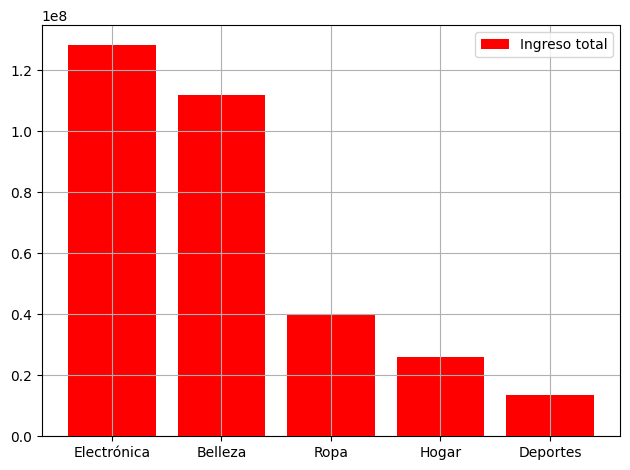

In [34]:
graficoDeBarras(df_IngresoTotalCategoria, "categoria", "ingreso_total", "Ingreso total")

In [35]:
df_IngresoTotalCiudad = sql("""
SELECT
    c.ciudad,
    SUM(cantidad * precio_unitario * (1 - descuento_pct / 100.0)) AS ingreso_total
FROM clientes c
JOIN ventas v
    ON c.cliente_id = v.cliente_id
JOIN productos p
    ON v.producto_id = p.producto_id
GROUP BY c.ciudad
ORDER BY ingreso_total DESC;
""")

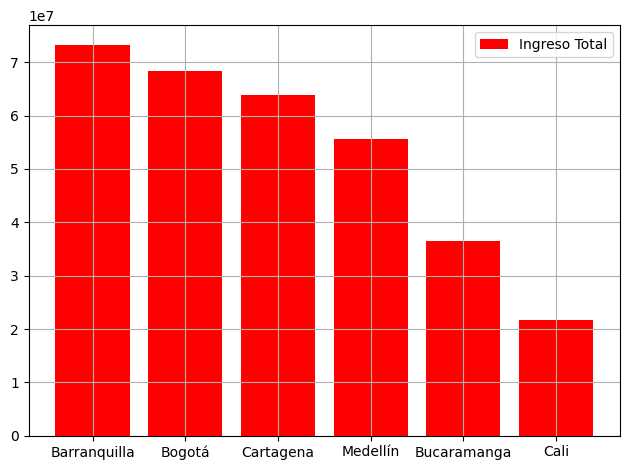

In [36]:
graficoDeBarras(df_IngresoTotalCiudad, "ciudad", "ingreso_total", "Ingreso Total")

In [37]:
df_PromedioSegmento = sql("""
SELECT
    c.segmento,
    AVG(
        v.cantidad * p.precio_unitario * (1 - v.descuento_pct / 100.0)
    ) AS ticket_promedio
FROM ventas v
JOIN clientes c
    ON v.cliente_id = c.cliente_id
JOIN productos p
    ON v.producto_id = p.producto_id
GROUP BY c.segmento
ORDER BY ticket_promedio DESC;
""")

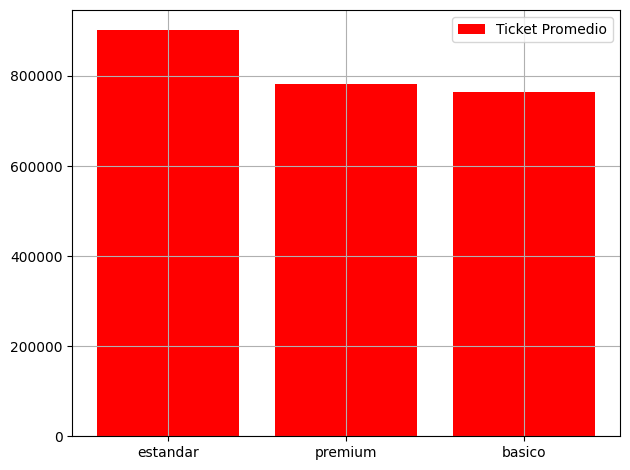

In [38]:
graficoDeBarras(df_PromedioSegmento, "segmento", "ticket_promedio", "Ticket Promedio")

# Conclusiones de negocio

## Categoria con mayores ingresos

In [39]:
prueba = sql("""
SELECT
    p.categoria,
    SUM(cantidad * precio_unitario * (1 - descuento_pct / 100.0)) AS ingreso_total
FROM ventas v
JOIN productos p
    ON v.producto_id = p.producto_id
GROUP BY p.categoria
ORDER BY ingreso_total DESC;
""")

In [40]:
prueba["porcentaje"] = ((prueba["ingreso_total"] / prueba["ingreso_total"].sum()) * 100).round(2)

In [41]:
prueba

,categoria,ingreso_total,porcentaje
0,Electrónica,128378110.0,40.22
1,Belleza,111751495.0,35.01
2,Ropa,39616945.0,12.41
3,Hogar,25918470.0,8.12
4,Deportes,13553645.0,4.25


In [43]:
sql("""
SELECT p.categoria, SUM(v.cantidad) AS TOTAL from productos p
    JOIN ventas v on p.producto_id = v.producto_id
GROUP BY p.categoria
ORDER BY TOTAL DESC
""")

,categoria,TOTAL
0,Electrónica,543
1,Belleza,418
2,Ropa,261
3,Deportes,176
4,Hogar,167


## Ciudad - Campaña de Marketing

In [45]:
pruebaIngresoTotal = sql("""
SELECT
    c.ciudad,
    SUM(cantidad * precio_unitario * (1 - descuento_pct / 100.0)) AS ingreso_total
FROM clientes c
JOIN ventas v 
    ON c.cliente_id = v.cliente_id
JOIN productos p
    ON v.producto_id = p.producto_id
GROUP BY c.ciudad
ORDER BY ingreso_total ASC;
""")

In [46]:
pruebaIngresoTotal

,ciudad,ingreso_total
0,Cali,21717755.0
1,Bucaramanga,36450380.0
2,Medellín,55615430.0
3,Cartagena,63803450.0
4,Bogotá,68367855.0
5,Barranquilla,73263795.0


In [47]:
pruebaClientesPorCiudad =  sql("""
SELECT
    c.ciudad,
    COUNT(c.nombre_cliente) AS Total_Personas
FROM clientes c
GROUP BY c.ciudad
ORDER BY Total_Personas ASC;
""")

In [48]:
pruebaClientesPorCiudad

,ciudad,Total_Personas
0,Cali,5
1,Bucaramanga,6
2,Medellín,9
3,Cartagena,12
4,Barranquilla,13
5,Bogotá,15


## Segmento con mayor ingresos

In [50]:
sql("""
SELECT
    c.segmento,
    AVG(
        v.cantidad * p.precio_unitario * (1 - v.descuento_pct / 100.0)
    ) AS ticket_promedio
FROM ventas v
JOIN clientes c
    ON v.cliente_id = c.cliente_id
JOIN productos p
    ON v.producto_id = p.producto_id
GROUP BY c.segmento
ORDER BY ticket_promedio DESC;
""")

,segmento,ticket_promedio
0,estandar,901342.645631
1,premium,781360.126582
2,basico,763985.425532


In [51]:
sql("""
SELECT
    segmento,
    COUNT(nombre_cliente) as TOTAL
FROM clientes
GROUP BY segmento
ORDER BY TOTAL DESC;
""")

,segmento,TOTAL
0,estandar,31
1,basico,16
2,premium,13
